In [1]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

In [2]:
import pandas as pd

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)\
    .drop(columns=['Reserve ESS Revenue ($k)'])

\begin{tabular}{llllllll}
\toprule
 & $r_1$ & $r_2$ & $r_3$ & $r_4$ & $r_5$ & $g$ & notes \\
$i$ &  &  &  &  &  &  &  \\
\midrule
1 & 2 & 4 & 6 & 4 & 7 & 7 & $\leftarrow \textit{most generalizable}$ \\
2 & \sqr{4} & \sqr{5} & \cir{4} & \sqr{8} & \cir{5} & 8,5 &  \\
3 & \sqr{7} & \cir{3} & \cir{2} & 7 & \sqr{8} & 8,7 &  \\
4 & \sqr{8} & \sqr{8} & \cir{1} & 5 & \cir{3} & 8,8 &  \\
5 & 3 & \sqr{9} & 5 & \cir{2} & \cir{2} & 9,5 & $\leftarrow \textit{example tradeoff}$ \\
6 & \cir{1} & 6 & \sqr{9} & 3 & 6 & 9,6 &  \\
7 & \sqr{9} & 7 & 8 & 6 & 4 & 9,8 & $\leftarrow \textit{no specialization}$ \\
8 & 5 & \cir{2} & 7 & \sqr{9} & \sqr{9} & 9,9 &  \\
9 & 6 & \cir{1} & 3 & \sqr{10} & \sqr{10} & 10,10,6 &  \\
10 & \sqr{10} & \sqr{10} & \sqr{10} & \cir{1} & \cir{1} & 10,10,10 & $\leftarrow \textit{least generalizable}$ \\
\bottomrule
\end{tabular}



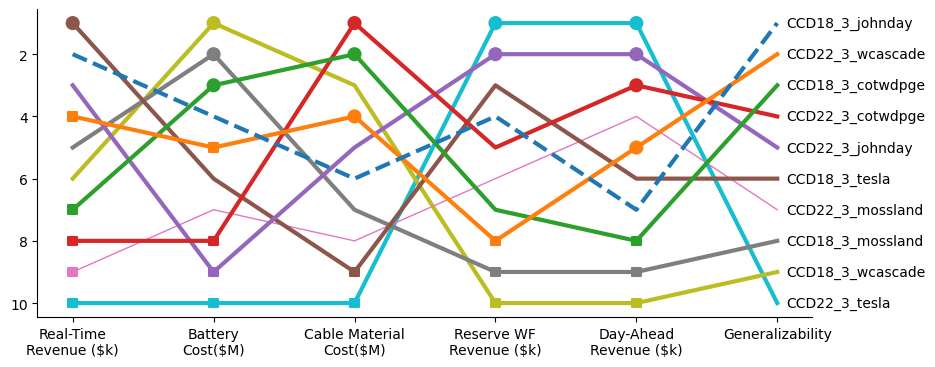

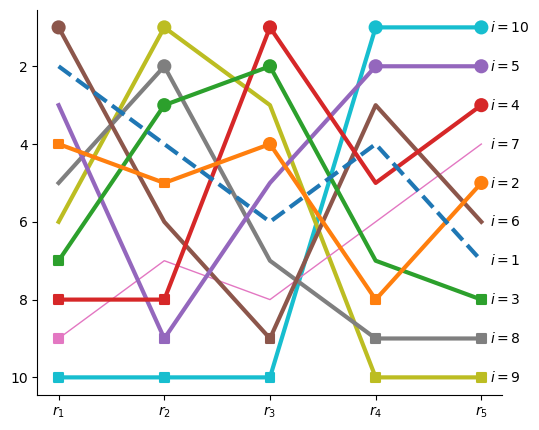

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from importlib import reload
import tradeoff_lattice as tl; reload(tl)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'

def sol_format(s):
    all = s.split('_')
    left = ' '.join(all[:-1])
    right = all[-1]
    return f'{left}\n{right}'
    
xlabels = {
    s: ovar_format(s)
    for s in ovars
}

ylabels = {
    s: sol_format(s)
    for s in df_design.index
}
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

def create_tradeoff_lattice():
    reload(tl)
    return tl.TradeoffLattice(
        df_design, ovars, dvars,
        ascending=ascending
    )
    
self = create_tradeoff_lattice()

plt.figure(figsize=(10, 4))
self.plot_pcp(
    x_labels=xlabels,
    # show_tradeoff=False, # uncomment to make squares not visible
    # show_generalizability_as=None # uncomment to hide the "Generalizability" column
)

rows = np.arange(len(self.rank.index)) + 1
cols = np.arange(len(self.rank.columns)) + 1

xticklabels = pd.Series([f'$r_{c}$' for c in cols], index=self.rank.columns)
yticklabels = pd.Series([f'$i = {r}$' for r in rows], index=self.rank.index)

plt.figure(figsize=(6, 5))
self.plot_pcp(
    x_labels=xticklabels.to_dict(),
    labels=yticklabels.to_dict(),
    # show_tradeoff=False, # uncomment to make squares not visible
    show_generalizability_as=None # uncomment to hide the "Generalizability" column
)

# plt.title('Parallel Coordinates Plot of Ranks')

plt.savefig('pcp-example.pdf', format='pdf', bbox_inches='tight')

index = pd.Index(rows, name='$i$')
notes = pd.Series(index=index, dtype=str)
notes[1] = '$\\leftarrow \\textit{most generalizable}$'
notes[5] = '$\\leftarrow \\textit{example tradeoff}$'
notes[7] = '$\\leftarrow \\textit{no specialization}$'
notes[10] = '$\\leftarrow \\textit{least generalizable}$'

print(self.to_latex(
    index=index,
    columns=xticklabels,
    notes=notes
))

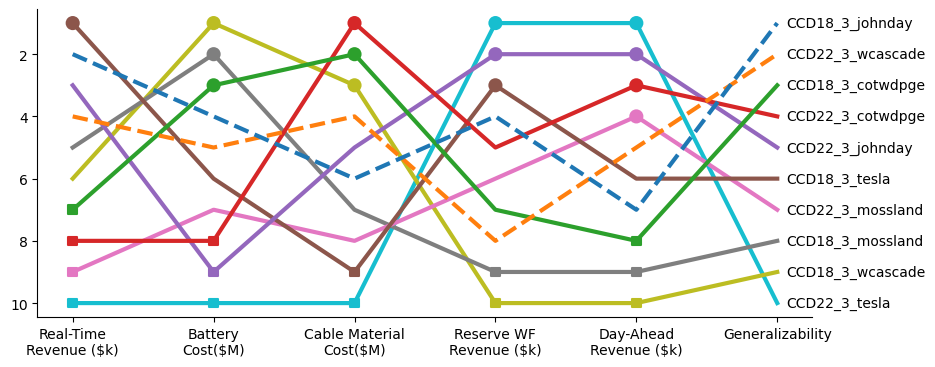

In [4]:
# we can also use the old threshold-based approach by specifying a k
# If we do this, then any rank above all generalizers is considered a specializer

self = create_tradeoff_lattice()

k = 2

plt.figure(figsize=(10, 4))
self.plot_pcp(
    x_labels=xlabels,
    specialization=self.specialization_at_k(k),
    generalizers=self.rank.index[:k],
)


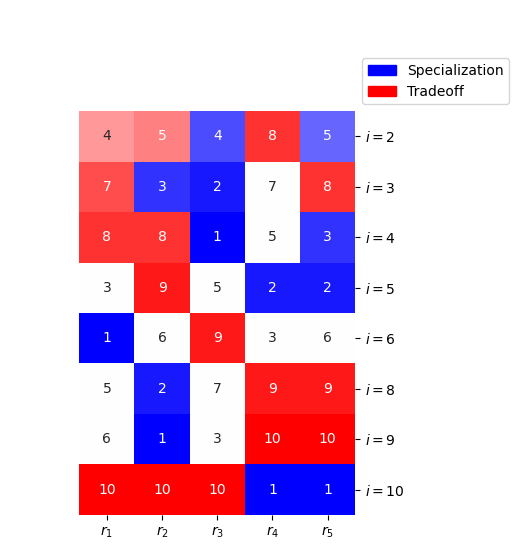

In [5]:
cm = create_tradeoff_lattice()\
    .plot_heatmap(
        figsize=(4, 5.6),
        xticklabels=xticklabels,
        yticklabels=yticklabels[self.specialization.index],
        row_cluster=False, # comment to show dendrogram on rows
        col_cluster=False # comment to show dendrogram on cols
    )

plt.sca(cm.ax_heatmap)
plt.yticks(rotation=0)

plt.savefig('heatmap-example.pdf', format='pdf', bbox_inches='tight')

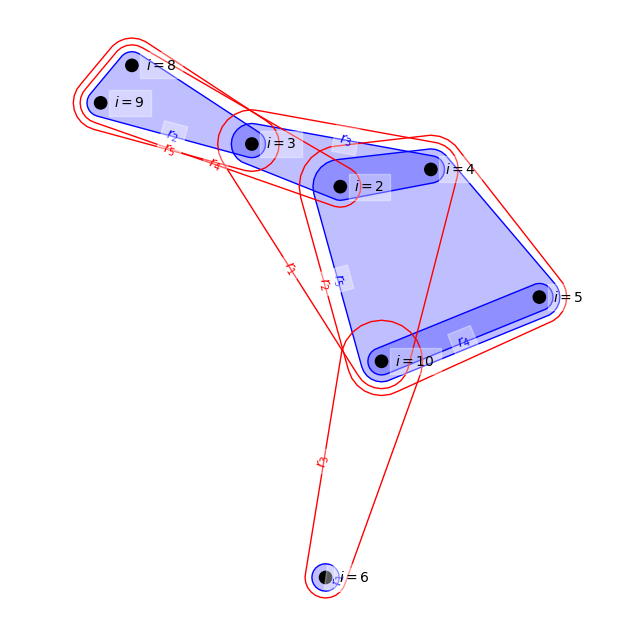

In [18]:
import networkx as nx

self.plot_specializers_and_tradeoff_as_hypergraph(
    edge_labels=xticklabels,
    node_labels=yticklabels,
    layout=nx.nx_agraph.graphviz_layout,
)

plt.savefig('specializer-tradeoff-euler.pdf', format='pdf', bbox_inches='tight')

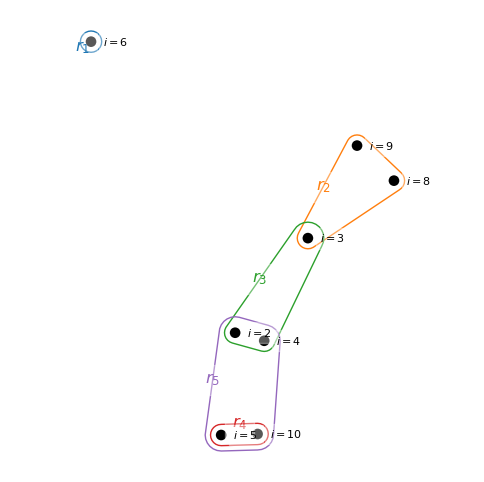

In [7]:
self = create_tradeoff_lattice()

kwargs = dict(
    # fill_edges=True,
    node_labels=yticklabels,
    edge_labels=xticklabels
)

plt.figure(figsize=(6, 6))
pos = self.plot_hypergraph_euler(
    return_pos=True,
    node_labels_kwargs=dict(fontsize=8),
    edge_labels_kwargs=dict(fontsize=12, rotation=0),
    **kwargs
)

plt.savefig('euler-example.pdf', format='pdf', bbox_inches='tight')

CCD18_3_wcascade     45.000000
CCD18_3_mossland     53.999993
CCD18_3_cotwdpge     54.300003
CCD22_3_wcascade     75.000000
CCD18_3_tesla        79.200000
CCD22_3_cotwdpge     90.499991
CCD22_3_johnday     117.500000
CCD22_3_tesla       131.999982
Name: Battery Rated Power(MW), dtype: float64

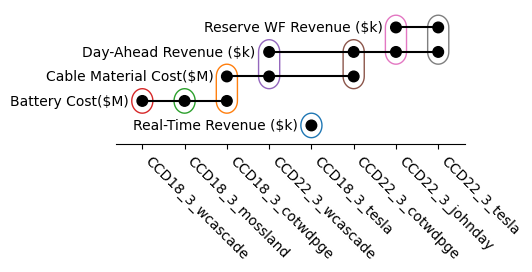

In [8]:
order_by = 'Battery Rated Power(MW)'

order = df_design.loc[self.specialization.index, order_by]\
    .sort_values()\
    .index

create_tradeoff_lattice()\
    .plot_hypergraph_upset(order=order)

df_design.loc[order, order_by]

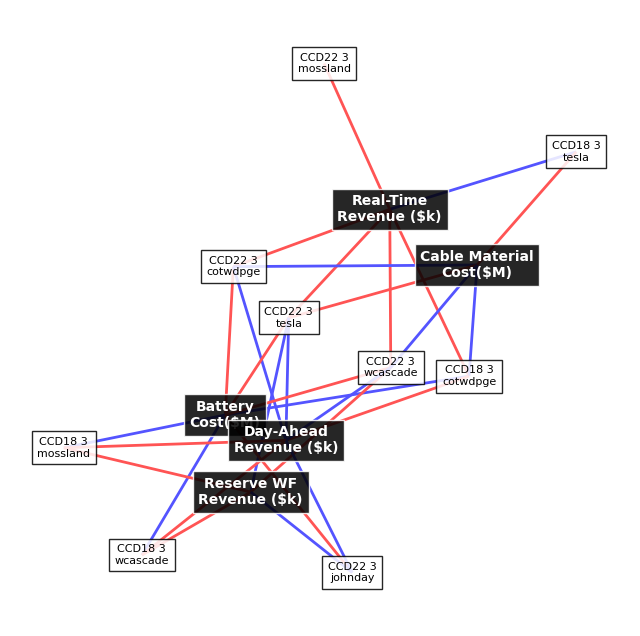

In [9]:
create_tradeoff_lattice()\
    .plot_tradeoff_lattice(
        labels={**xlabels, **ylabels}, 
        layout=tl.nx.kamada_kawai_layout
        # layout_kwargs=dict(prog='neato')
    )